# Baseline Models - Auto-Urgency Tagging (LEN-05)
1. **Logistic Regression** — cepat, interpretatif, sebagai acuan minimum
2. **Random Forest** — ensemble berbasis pohon, lebih robust terhadap noise

Kedua model dikonfigurasi dengan `class_weight='balanced'` untuk menangani ketidakseimbangan distribusi kelas.


## Cell 1 — Setup Lingkungan & Import Library

In [16]:
import sys
import os

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    
    PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research'
    if not os.path.exists(PROJECT_ROOT):
        PROJECT_ROOT = '/content/drive/MyDrive/lentera-ml-research'
        
    os.chdir(PROJECT_ROOT)
    print(f"Berjalan di Google Colab. Direktori aktif saat ini: {os.getcwd()}")
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    print(f"Berjalan secara lokal. Project root: {PROJECT_ROOT}")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import split_data, extract_tfidf

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Berjalan di Google Colab. Direktori aktif saat ini: /content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research



## Cell 2 — Load & Validasi Dataset Bersih

In [17]:
# Membaca dataset yang telah melalui proses pembersihan teks (output dari LEN-03)
# Menggunakan os.path.join dengan PROJECT_ROOT agar kompatibel baik secara lokal maupun di Colab.
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'cleaned_complaints.csv')

df = pd.read_csv(DATA_PATH)
print(f"Dataset berhasil dimuat. Shape awal: {df.shape}")
print(f"Kolom tersedia: {df.columns.tolist()}")
print()

# Kolom `Cleaned_Narrative` adalah input teks dan `Urgency` adalah target label.
df = df.dropna(subset=['Cleaned_Narrative', 'Urgency'])
print(f"Shape setelah dropna: {df.shape}")
print()

# Cek distribusi kelas untuk memahami tingkat ketidakseimbangan dataset
print("Distribusi kelas Urgency:")
print(df['Urgency'].value_counts())

Dataset berhasil dimuat. Shape awal: (121485, 3)
Kolom tersedia: ['Raw_Filtered_Narrative', 'Cleaned_Narrative', 'Urgency']

Shape setelah dropna: (121485, 3)

Distribusi kelas Urgency:
Urgency
High      52471
Medium    49583
Low       19431
Name: count, dtype: int64



## Cell 3 — Visualisasi Distribusi Kelas

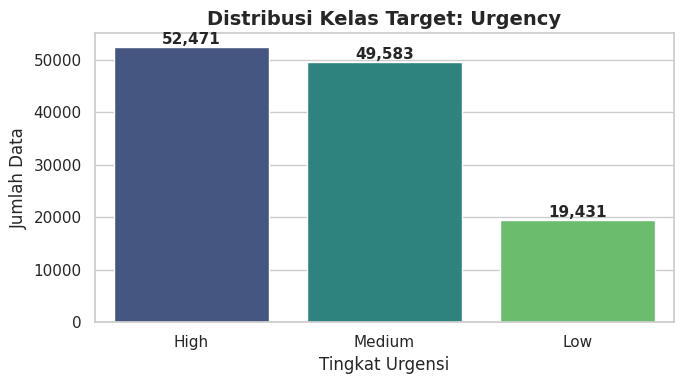

In [18]:
# Memvisualisasikan distribusi kelas target untuk mengkonfirmasi adanya
# ketidakseimbangan kelas (class imbalance) yang menjadi dasar penggunaan
# parameter `class_weight='balanced'` pada model.
order = ['High', 'Medium', 'Low']
counts = df['Urgency'].value_counts().reindex(order)

plt.figure(figsize=(7, 4))
bars = sns.barplot(x=counts.index, y=counts.values, palette='viridis', hue=counts.index, legend=False)

for bar in bars.patches:
    bars.annotate(
        f'{int(bar.get_height()):,}',
        (bar.get_x() + bar.get_width() / 2., bar.get_height()),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.title('Distribusi Kelas Target: Urgency', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Urgensi')
plt.ylabel('Jumlah Data')
plt.tight_layout()
plt.show()


## Cell 4 — Data Splitting (Pipeline LEN-04)

In [19]:
# Memanggil fungsi `split_data()` dari pipeline LEN-04 (src/features.py).
df_train, df_val, df_test = split_data(
    df,
    text_col='Cleaned_Narrative',
    target_col='Urgency'
)

y_train = df_train['Urgency']
y_val   = df_val['Urgency']
y_test  = df_test['Urgency']

print("\nDistribusi kelas pada setiap split:")
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"  {name}: {y.value_counts().to_dict()}")

Train size: 85039, Val size: 18223, Test size: 18223

Distribusi kelas pada setiap split:
  Train: {'High': 36729, 'Medium': 34708, 'Low': 13602}
  Val: {'High': 7871, 'Medium': 7438, 'Low': 2914}
  Test: {'High': 7871, 'Medium': 7437, 'Low': 2915}



## Cell 5 — Ekstraksi Fitur TF-IDF (Pipeline LEN-04)

In [20]:
# Memanggil fungsi `extract_tfidf()` dari pipeline LEN-04 (src/features.py).
X_train_tfidf, X_val_tfidf, X_test_tfidf, tfidf_vectorizer = extract_tfidf(
    train_texts=df_train['Cleaned_Narrative'],
    val_texts=df_val['Cleaned_Narrative'],
    test_texts=df_test['Cleaned_Narrative']
)

print(f"Shape fitur TF-IDF:")
print(f"  X_train : {X_train_tfidf.shape}")
print(f"  X_val   : {X_val_tfidf.shape}")
print(f"  X_test  : {X_test_tfidf.shape}")
print(f"\nUkuran vocabulary TF-IDF: {len(tfidf_vectorizer.vocabulary_)} kata")

Shape fitur TF-IDF:
  X_train : (85039, 5000)
  X_val   : (18223, 5000)
  X_test  : (18223, 5000)

Ukuran vocabulary TF-IDF: 5000 kata


In [21]:
fitur_names = tfidf_vectorizer.get_feature_names_out()
print(fitur_names[2000:2050])

['federal consumer' 'federal consumer protection' 'federal credit'
 'federal credit union' 'federal law' 'federal state' 'federal state law'
 'federal student' 'federal student loan' 'federal trade'
 'federal trade commission' 'federally' 'federally protect'
 'federally protect consumer' 'fee' 'fee account' 'fee assess'
 'fee charge' 'fee moneyamount' 'feel' 'feel item' 'feel item report'
 'feel like' 'fha' 'field' 'fifth' 'fight' 'figure' 'file' 'file account'
 'file cfpb' 'file claim' 'file complaint' 'file complaint consumer'
 'file complaint inaccurate' 'file consumer' 'file datemask'
 'file dispute' 'file formal' 'file formal complaint' 'file ftc'
 'file ftc identity' 'file item' 'file police' 'file police report'
 'file report' 'file request' 'file request pursuant' 'file right'
 'file right fair']



## Cell 6 — Model 1: Logistic Regression

In [22]:
# --- PELATIHAN: Logistic Regression ---
# Logistic Regression dipilih sebagai baseline minimum yang cepat dan interpretatif.
# Parameter penting:
#   - class_weight='balanced'  : mengkompensasi ketidakseimbangan kelas secara otomatis
#                                dengan menaikkan bobot pada kelas minoritas.
#   - max_iter=1000            : iterasi lebih banyak agar model konvergen pada data besar.
#   - random_state=42          : reproducibility hasil.
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

print("Melatih Logistic Regression...")
lr_model.fit(X_train_tfidf, y_train)
print("Pelatihan selesai.")

Melatih Logistic Regression...
Pelatihan selesai.



## Cell 7 — Evaluasi Logistic Regression pada Test Set

In [23]:
# Melakukan prediksi pada test set menggunakan model Logistic Regression
# yang telah dilatih. Test set bersifat held-out dan TIDAK pernah dilihat model
y_pred_lr = lr_model.predict(X_test_tfidf)

print("  EVALUASI MODEL 1: Logistic Regression (Test Set)")

print(classification_report(
    y_test,
    y_pred_lr,
    labels=['High', 'Medium', 'Low'],
    target_names=['High', 'Medium', 'Low']
))

  EVALUASI MODEL 1: Logistic Regression (Test Set)
              precision    recall  f1-score   support

        High       0.93      0.82      0.87      7871
      Medium       0.84      0.79      0.82      7437
         Low       0.57      0.83      0.68      2915

    accuracy                           0.81     18223
   macro avg       0.78      0.82      0.79     18223
weighted avg       0.84      0.81      0.82     18223




## Cell 8 — Confusion Matrix Logistic Regression

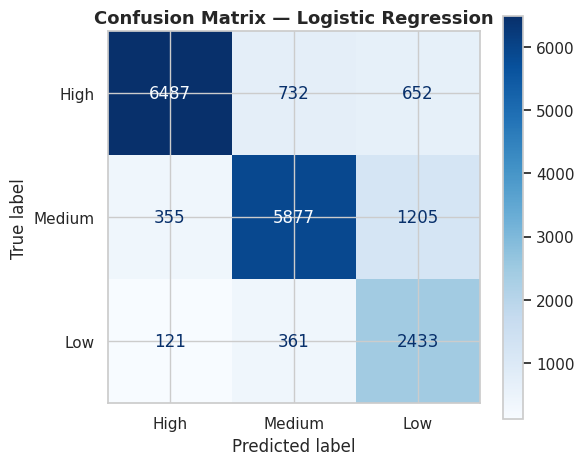

In [24]:
# Visualisasi Confusion Matrix untuk melihat pola kesalahan prediksi
# antar kelas secara lebih intuitif.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    labels=['High', 'Medium', 'Low'],
    display_labels=['High', 'Medium', 'Low'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Cell 9 — Model 2: Random Forest

In [25]:
# --- PELATIHAN: Random Forest ---
# Random Forest adalah model ensemble yang lebih kompleks dan umumnya lebih
# robust terhadap noise dibandingkan Logistic Regression.
# Parameter penting:
#   - n_estimators=200         : jumlah pohon keputusan dalam ensemble.
#   - class_weight='balanced'  : penanganan class imbalance (wajib, sama seperti LR).
#   - n_jobs=-1                : memanfaatkan seluruh core CPU untuk mempercepat pelatihan.
#   - random_state=42          : reproducibility hasil.
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

print("Melatih Random Forest (200 trees)")
rf_model.fit(X_train_tfidf, y_train)
print("Pelatihan selesai.")

Melatih Random Forest (200 trees)
Pelatihan selesai.



## Cell 10 — Evaluasi Random Forest pada Test Set

In [26]:
# Melakukan prediksi pada test set menggunakan model Random Forest
y_pred_rf = rf_model.predict(X_test_tfidf)

print("  EVALUASI MODEL 2: Random Forest (Test Set)")

# Classification Report: Precision, Recall, F1-Score per kelas
print(classification_report(
    y_test,
    y_pred_rf,
    labels=['High', 'Medium', 'Low'],
    target_names=['High', 'Medium', 'Low']
))

  EVALUASI MODEL 2: Random Forest (Test Set)
              precision    recall  f1-score   support

        High       0.93      0.88      0.91      7871
      Medium       0.82      0.90      0.86      7437
         Low       0.75      0.67      0.71      2915

    accuracy                           0.86     18223
   macro avg       0.84      0.82      0.82     18223
weighted avg       0.86      0.86      0.86     18223




## Cell 11 — Confusion Matrix Random Forest

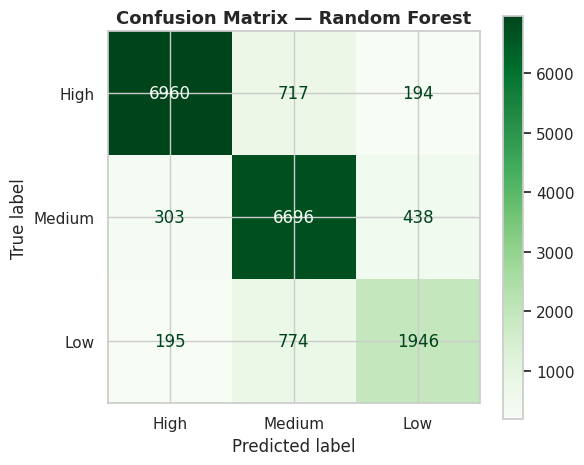

In [27]:
# Visualisasi Confusion Matrix untuk Random Forest
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    labels=['High', 'Medium', 'Low'],
    display_labels=['High', 'Medium', 'Low'],
    cmap='Greens',
    ax=ax
)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Cell 12 — Perbandingan Performa Kedua Model (Ringkasan)

In [28]:
from sklearn.metrics import f1_score, accuracy_score

# Membuat tabel ringkasan perbandingan metrik utama kedua model
# untuk memudahkan pengambilan keputusan model mana yang akan
# digunakan lebih lanjut (handoff ke tim evaluasi - LEN-09).
results = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1-Score Macro': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ],
    'F1-Score Weighted': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted')
    ]
}

df_results = pd.DataFrame(results)

df_results[['Accuracy', 'F1-Score Macro', 'F1-Score Weighted']] = \
    df_results[['Accuracy', 'F1-Score Macro', 'F1-Score Weighted']].map(lambda x: f'{x:.4f}')

print("  RINGKASAN PERBANDINGAN PERFORMA MODEL BASELINE")
print(df_results.to_string(index=False))
print()
print("Catatan: F1-Score Macro diprioritaskan sebagai metrik utama")
print("         karena dataset memiliki ketidakseimbangan kelas.")

  RINGKASAN PERBANDINGAN PERFORMA MODEL BASELINE
              Model Accuracy F1-Score Macro F1-Score Weighted
Logistic Regression   0.8120         0.7886            0.8188
      Random Forest   0.8562         0.8246            0.8554

Catatan: F1-Score Macro diprioritaskan sebagai metrik utama
         karena dataset memiliki ketidakseimbangan kelas.



## Cell 13 — Visualisasi Perbandingan F1-Score per Kelas

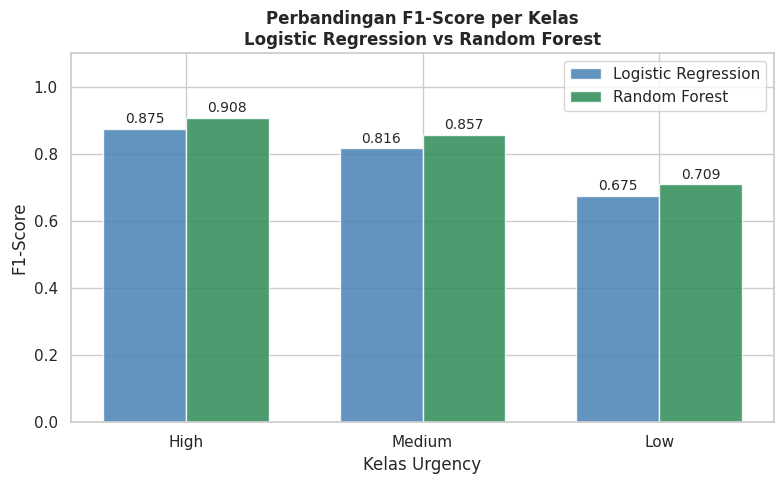

In [29]:
from sklearn.metrics import classification_report

# Mengekstrak F1-Score per kelas dari kedua model untuk visualisasi
# perbandingan side-by-side yang lebih mudah dibaca.
classes = ['High', 'Medium', 'Low']

report_lr = classification_report(y_test, y_pred_lr, labels=classes, target_names=classes, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, labels=classes, target_names=classes, output_dict=True)

f1_lr = [report_lr[c]['f1-score'] for c in classes]
f1_rf = [report_rf[c]['f1-score'] for c in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, f1_lr, width, label='Logistic Regression', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_rf, width, label='Random Forest', color='seagreen', alpha=0.85)

# Tambahkan nilai di atas setiap bar
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)

ax.set_xlabel('Kelas Urgency')
ax.set_ylabel('F1-Score')
ax.set_title('Perbandingan F1-Score per Kelas\nLogistic Regression vs Random Forest', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

In [30]:
# Export trained models dan TF-IDF vectorizer untuk digunakan oleh backend
from pathlib import Path
import joblib

export_dir = Path(PROJECT_ROOT) / 'models'
export_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(lr_model, export_dir / 'logistic_regression.joblib')
joblib.dump(rf_model, export_dir / 'random_forest.joblib')
joblib.dump(tfidf_vectorizer, export_dir / 'tfidf_vectorizer.joblib')
joblib.dump(['High', 'Medium', 'Low'], export_dir / 'label_order.joblib')

print('Saved backend artifacts to:')
print(f' - {export_dir / "logistic_regression.joblib"}')
print(f' - {export_dir / "random_forest.joblib"}')
print(f' - {export_dir / "tfidf_vectorizer.joblib"}')
print(f' - {export_dir / "label_order.joblib"}')


Saved backend artifacts to:
 - /content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research/models/logistic_regression.joblib
 - /content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research/models/random_forest.joblib
 - /content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research/models/tfidf_vectorizer.joblib
 - /content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research/models/label_order.joblib
